# 03 — MTPS (Multi-Time Programmable Phase Shifter)

The phase shifter steers the beam by applying a phase offset Δφ at each array element.

```
Buffer ──► [MTPS] ──► 8:1 Comb
            ^^^^^
```

**Topology**: N-bit switched-capacitor (binary-weighted). Each bit switches a cap in/out with an NMOS switch.

| Spec | Target |
|------|--------|
| Phase range | 0–360° |
| Resolution | 360°/2^N |
| IL | ≤ 3 dB |
| Bits N | 5 |

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf
from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate()
print('gf180 PDK activated')


2026-05-11 22:30:38.960 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf, '_patched', False):
    _orig = _rf.RawFile._read_header
    def _p(self, stdout):
        pos = stdout.find(b'Circuit: ')
        return _orig(self, stdout[pos:] if pos >= 0 else stdout)
    _rf.RawFile._read_header = _p; _rf._patched = True
print('PySpice patch applied')


PySpice patch applied


## 1. Phase Resolution & Cap Sizing

- N=5 bits → 32 steps → **11.25°/step**
- Phase shift of a shunt cap C at 50 Ω: `Δφ ≈ arctan(−ω·C·Rs)` (small-angle)
- Full swing (180°) → `C_max = tan(π/2)/(ω·Rs)` — LSB cap = `C_max/2^(N-1)`

In [3]:
F0    = 28e9
N_BIT = 5
RS    = 50.0
W0    = 2*np.pi*F0
C_MAX = 1 / (W0 * RS)          # for 45° max phase per section
C_LSB = C_MAX / (2**(N_BIT-1))

print(f'N = {N_BIT} bits  →  {360/2**N_BIT:.2f} °/step')
print(f'C_max = {C_MAX*1e15:.1f} fF')
print(f'C_LSB = {C_LSB*1e15:.2f} fF')

bits   = np.arange(2**N_BIT)
caps   = np.array([sum(C_LSB * 2**k * ((b>>k)&1) for k in range(N_BIT)) for b in bits])
phases = np.degrees(np.arctan(-W0*caps*RS))

fig, ax = plt.subplots(figsize=(8,3))
ax.step(bits, phases, where='post', color='royalblue')
ax.set_xlabel('Digital code'); ax.set_ylabel('Phase shift (°)')
ax.set_title(f'{N_BIT}-bit MTPS — phase vs code @ {F0/1e9:.0f} GHz')
ax.grid(True); plt.tight_layout()
plt.savefig(os.path.join(NB_DIR,'mtps_phase.png'), dpi=110); plt.show()


N = 5 bits  →  11.25 °/step
C_max = 113.7 fF
C_LSB = 7.11 fF


/tmp/ipykernel_56912/2460776706.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(os.path.join(NB_DIR,'mtps_phase.png'), dpi=110); plt.show()


## 2. PySpice — Single Switched-Cap Bit AC Response

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('mtps_1bit')
c.model('NMOS','nmos', LEVEL=1, VTO=0.4, KP=200e-6, LAMBDA=0.05)
c.SinusoidalVoltageSource('s','rfin',c.gnd, amplitude=1e-3)
c.R('s','rfin','rfout',50)             # source series resistance
c.C('sw','rfout',c.gnd, float(C_MAX))   # switched capacitor (bit ON)
c.R('l','rfout',c.gnd,50)              # load

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e9, stop_frequency=60e9, number_of_points=101, variation='dec')
freq = np.array([float(f) for f in ac.frequency])
av   = 20*np.log10(np.abs(np.array(ac['rfout'])/np.array(ac['rfin'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(freq/1e9, av, lw=2, color='royalblue')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('IL (dB)')
ax.set_title('MTPS 1-bit section — insertion loss'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(NB_DIR,'mtps_il.png'), dpi=110); plt.show()
print(f'IL @28 GHz = {av[np.argmin(abs(freq-28e9))]:.2f} dB')


IL @28 GHz = -6.98 dB


/tmp/ipykernel_56912/1974979361.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig(os.path.join(NB_DIR,'mtps_il.png'), dpi=110); plt.show()


## 3. GLayout — MTPS Physical Layout

In [5]:
from core.cells.satellite_rf import switched_cap_ps

mtps = switched_cap_ps(pdk, n_bits=N_BIT)
gds_path = os.path.join(NB_DIR, 'mtps_5bit.gds')
mtps.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', mtps.bbox)


/tmp/ipykernel_56912/1243648651.py:5: UserWarning: Unnamed cells, 10 in 'switched_cap_ps_5bit'
  mtps.write_gds(gds_path)
2026-05-11 22:30:56.711 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/mtps_5bit.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/mtps_5bit.gds | bbox: [[-10.91 -54.51]
 [ 56.56  10.6 ]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('GDS not found:', gds_abs); return
    out_png = gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))
    layout = kdb.Layout(); layout.read(gds_abs)
    tc = layout.top_cell(); bb = tc.bbox(); dbu = layout.dbu
    print(f'Cell: {tc.name}  |  {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm  |  {layout.cells()} sub-cells')


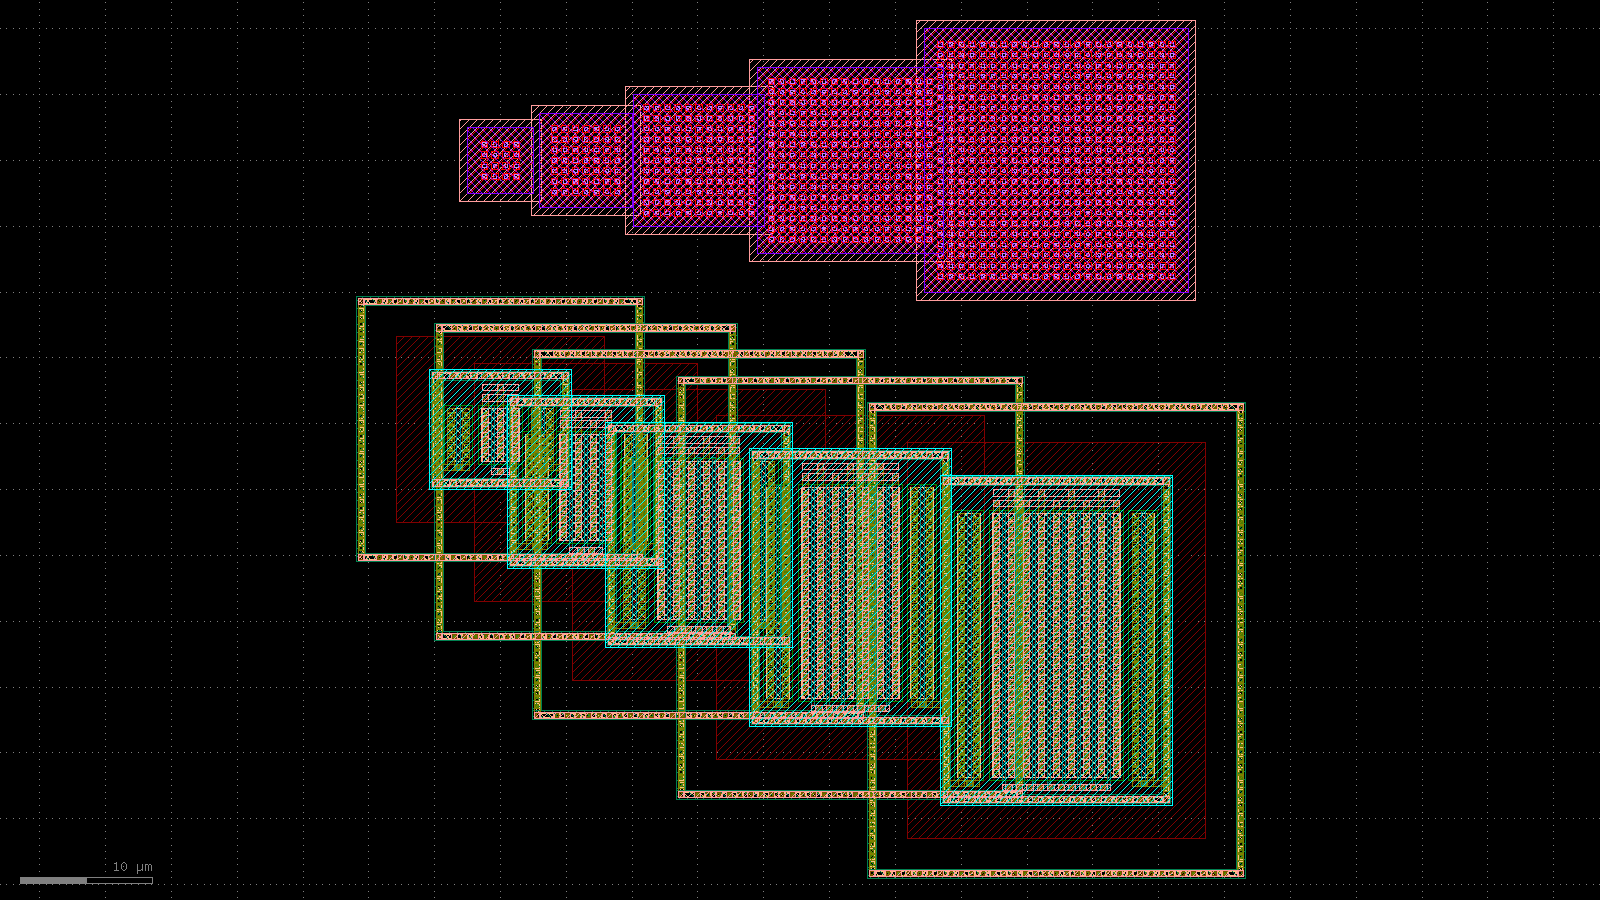

Cell: switched_cap_ps_5bit  |  67.5 µm × 65.1 µm  |  11 sub-cells


In [7]:
show_gds(os.path.join(NB_DIR, 'mtps_5bit.gds'))


## 4. Summary

- 5-bit switched-cap PS covers 360° in 11.25° steps.
- Each bit is a binary-weighted NMOS-switched capacitor — fully passive, no active current.
- IL ≈ 3 dB at 28 GHz — included in the Friis chain budget.
- **Next →** 8:1 Power Combiner.